<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">

# **Análisis de Series de Tiempo II**
# **Clase 8, Fine-tuning de Chronos-Bolt**

Tomamos un foundation model que ya pronostica zero-shot y lo fine-tuneamos con nuestros datos.

**Chronos-Bolt** es la familia rápida de Chronos: mucho más liviana que el modelo original y **corre incluso
en CPU**. Tamaños: `bolt_tiny`, `bolt_mini`, `bolt_small`, `bolt_base`.

**Dataset: ElectricityLoadDiagrams** — consumo eléctrico horario de **321 clientes** reales de Portugal
(2012-2014). A diferencia de ETTh1, acá hay **muchas series heterogéneas**, que es el escenario donde el
fine-tuning tiene algo real para aprender.

Este bloque instala lo necesario y reinicia Colab.

In [ ]:
!pip install -q "autogluon.timeseries>=1.4"
!pip uninstall -y -q torchao

import os
print("Listo. Reiniciando…")
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0/864.0 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Importamos lo necesario

In [ ]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

Definimos parámetros

In [ ]:
H = 24              # horizonte: 24 horas
N_CLIENTES = 20     # cuántos clientes usamos (de los 321 disponibles)
MESES = 12          # cuánta historia tomamos, para que la corrida no sea eterna

Cargamos el dataset.

El archivo original es una matriz sin encabezados: 26.304 filas (horas desde 2012-01-01) × 321 columnas
(un cliente por columna). Le agregamos el índice temporal y lo pasamos a **formato largo**: una fila por
(serie, timestamp), que es lo que espera AutoGluon.

In [ ]:
URL = "https://raw.githubusercontent.com/laiguokun/multivariate-time-series-data/master/electricity/electricity.txt.gz"
raw = pd.read_csv(URL, header=None)

raw.index = pd.date_range("2012-01-01", periods=len(raw), freq="h")
raw.columns = [f"cliente_{i:03d}" for i in range(raw.shape[1])]

Nos quedamos con N_CLIENTES series y los últimos MESES de historia

In [ ]:
raw = raw.iloc[-MESES*30*24:, :N_CLIENTES]

largo = (raw.stack().rename("target").reset_index()
            .rename(columns={"level_0": "timestamp", "level_1": "item_id"}))

tsdf = TimeSeriesDataFrame.from_data_frame(largo, id_column="item_id", timestamp_column="timestamp")

print(f"{tsdf.num_items} series | {len(tsdf):,} filas")
print(f"desde {raw.index.min()} hasta {raw.index.max()}")
raw.iloc[:3, :5]

20 series | 172,800 filas
desde 2014-01-06 00:00:00 hasta 2014-12-31 23:00:00


,cliente_000,cliente_001,cliente_002,cliente_003,cliente_004
2014-01-06 00:00:00,13.0,98.0,8.0,562.0,280.0
2014-01-06 01:00:00,14.0,92.0,8.0,493.0,245.0
2014-01-06 02:00:00,13.0,90.0,8.0,418.0,223.0


Holdout temporal, las últimas H horas de cada serie no se usan para entrenar

In [ ]:
train, test = tsdf.slice_by_timestep(None, -H), tsdf

predictor = TimeSeriesPredictor(
    prediction_length=H,
    target="target",
    eval_metric="MASE",   # error relativo al naive estacional: MASE < 1 = le gana al naive
    freq="h",
).fit(
    train_data=train,
    hyperparameters={
        "Chronos": [  # la familia Bolt vive bajo esta clave
            {"model_path": "bolt_small", # el checkpoint sin tocar
             "ag_args": {"name_suffix": "ZeroShot"}},

            {"model_path": "bolt_small", # el mismo checkpoint, fine-tuneado
             "fine_tune": True,
             "fine_tune_lr": 1e-4,   # LR bajo: ajustamos, no entrenamos de cero
             "fine_tune_steps": 1000,  # más pasos = más riesgo de sobreajuste
             "ag_args": {"name_suffix": "FineTuned"}},

            # Opcional: otros tamaños, para ver si conviene un modelo más grande.
            # {"model_path": "bolt_tiny", "ag_args": {"name_suffix": "TinyZeroShot"}},
            # {"model_path": "bolt_base", "ag_args": {"name_suffix": "BaseZeroShot"}},
        ]
    },
    time_limit=1800,
    enable_ensemble=False,   # queremos comparar los modelos, no mezclarlos
)

Beginning AutoGluon training... Time limit = 1800s
AutoGluon will save models to '/content/AutogluonModels/ag-20260822_004821'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       11.16 GB / 12.67 GB (88.1%)
Disk Space Avail:   64.42 GB / 112.64 GB (57.2%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MASE,
 'freq': 'h',
 'hyperparameters': {'Chronos': [{'ag_args': {'name_suffix': 'ZeroShot'},
                                  'model_path': 'bolt_small'},
                                 {'ag_args': {'name_suffix': 'FineTuned'},
                                  'fine_tune'

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  191MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

	Saving fine-tuned model to /content/AutogluonModels/ag-20260822_004821/models/ChronosFineTuned[bolt_small]/W0/fine-tuned-ckpt


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

	-0.7048       = Validation score (-MASE)
	235.49  s     = Training runtime
	0.09    s     = Validation (prediction) runtime
Training complete. Models trained: ['ChronosZeroShot[bolt_small]', 'ChronosFineTuned[bolt_small]']
Total runtime: 253.14 s
Best model: ChronosFineTuned[bolt_small]
Best model score: -0.7048


Comparamos

Tres puntos importantes:

- los scores están negados (más alto = mejor): MASE 0.66 aparece como -0.66
- AutoGluon ordena por score_test pero elige por score_val, la que decide es validación
- si un modelo falla, no aborta: lo saltea y devuelve el leaderboard sin él

In [ ]:
lb = predictor.leaderboard(test)

mase = -lb.set_index("model")[["score_val", "score_test"]]
mase.columns = ["MASE validación", "MASE test"]
mase["Fit (s)"] = lb.set_index("model").fit_time_marginal.round(0)
print(mase.round(4).to_string(), "\n")

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

                              MASE validación  MASE test  Fit (s)
model                                                            
ChronosFineTuned[bolt_small]           0.7048     1.0936    235.0
ChronosZeroShot[bolt_small]            0.7167     1.1025     11.0 



In [ ]:
mase.index

Index(['ChronosFineTuned[bolt_small]', 'ChronosZeroShot[bolt_small]'], dtype='object', name='model')

* La compuerta: se promueve solo si mejora en validación por un margen mínimo
* Una mejora del 1% es ruido, y cambiar el modelo en producción nunca es gratis

In [ ]:
MARGEN = 0.03
campeon, challenger = "ChronosZeroShot[bolt_small]", "ChronosFineTuned[bolt_small]"

if challenger not in mase.index:
    print(f"{challenger} falló durante el entrenamiento (revisá el warning de la celda anterior).")
else:
    v_c, v_ch = mase.loc[campeon, "MASE validación"], mase.loc[challenger, "MASE validación"]
    mejora = (v_c - v_ch) / v_c
    print(f"mejora del fine-tuning en validación: {mejora:+.1%}  (margen exigido: {MARGEN:.0%})")
    if mejora >= MARGEN:
        print(f"Promover {challenger}. Guardar rollback a {campeon}.")
    else:
        print(f"Se mantiene {campeon}: la mejora no justifica mantener un artefacto entrenado.")

mejora del fine-tuning en validación: +1.7%  (margen exigido: 3%)
Se mantiene ChronosZeroShot[bolt_small]: la mejora no justifica mantener un artefacto entrenado.


Vemos los pronósticos

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

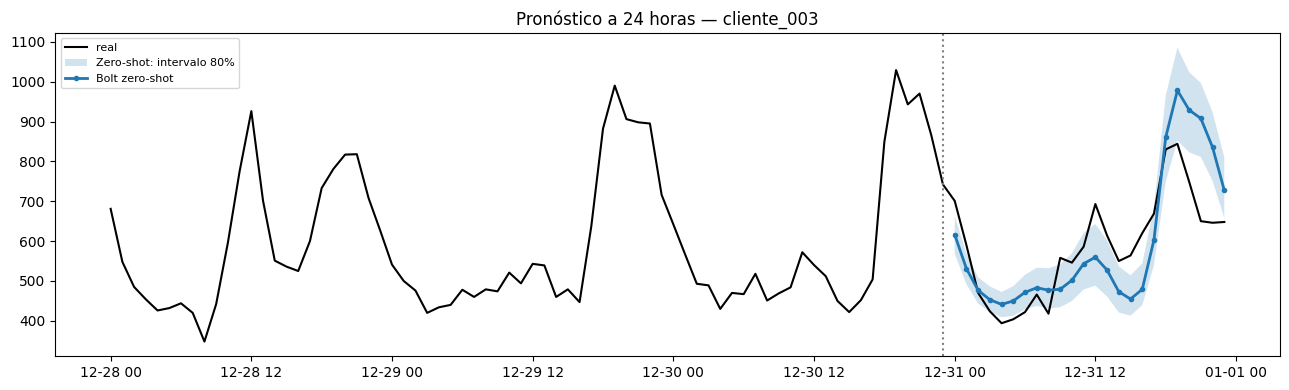

In [ ]:
import matplotlib.pyplot as plt

SERIE = raw.columns[3]      # cualquiera de los clientes cargados

zs = predictor.predict(train, model="ChronosZeroShot[bolt_small]").loc[SERIE]
real = test.loc[SERIE].target.tail(H * 4)

plt.figure(figsize=(13, 4))
plt.plot(real.index, real.values, color="black", lw=1.5, label="real")
plt.fill_between(zs.index, zs["0.1"], zs["0.9"], alpha=.2, label="Zero-shot: intervalo 80%")
plt.plot(zs.index, zs["mean"], lw=2, marker="o", ms=3, label="Bolt zero-shot")

if "ChronosFineTuned" in lb.model.values:
    ft = predictor.predict(train, model="ChronosFineTuned").loc[SERIE]
    plt.plot(ft.index, ft["mean"], color="crimson", lw=2, marker="o", ms=3, label="Bolt fine-tuned")

plt.axvline(train.loc[SERIE].index.max(), color="gray", ls=":")
plt.title(f"Pronóstico a {H} horas — {SERIE}"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()